In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv').drop_duplicates()

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,pioneer araya,sector 62,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,10.0,North-East,Relatively New,J69118026,5514.0,NaN,NaN,0,1,0,0,0,0,153
1,house,independent,sector 40,9.50,40135.0,2367.0,Plot area 263(219.9 sq.m.),12,12,3+,4.0,NaN,New Property,G69453034,NaN,2367.0,NaN,0,0,1,0,0,0,57
2,flat,m3m golf hills,sector 79,1.45,10211.0,1420.0,Carpet area: 1420 (131.92 sq.m.),2,2,3 Balconies,15.0,NaN,Under Construction,D69857690,NaN,NaN,1420.0,0,0,0,0,0,2,67
3,house,independent,sector 39,1.60,17937.0,892.0,Plot area 892(82.87 sq.m.),1,1,2,2.0,NaN,Old Property,X67948578,NaN,892.0,NaN,0,0,0,0,0,2,40
4,flat,tulip purple,sector 69,1.92,8000.0,2400.0,Super Built up area 2400(222.97 sq.m.),4,5,3+ Balconies,5.0,East,Relatively New,O69569386,2400.0,NaN,NaN,0,1,0,0,0,0,158


In [5]:
df.shape

(3677, 24)

In [6]:
df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area',
       'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing',
       'agePossession', 'property_id', 'super_built_up_area', 'built_up_area',
       'carpet_area', 'study room', 'servant room', 'store room', 'pooja room',
       'others', 'furnishing_type', 'luxury_score'],
      dtype='object')

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\2797181776.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price'])


<Axes: xlabel='price', ylabel='Density'>

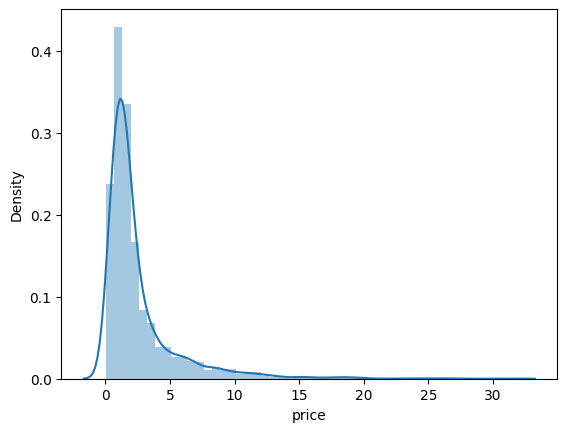

In [7]:
# outliers on the basis of price column
sns.distplot(df['price'])

<Axes: xlabel='price'>

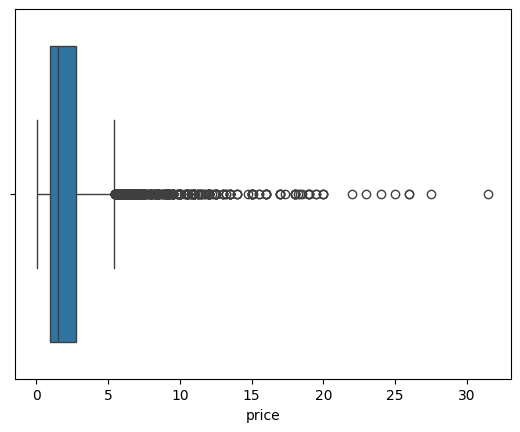

In [8]:
sns.boxplot(x=df['price'])

In [9]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(425,
 count    425.000000
 mean       9.235624
 std        4.065259
 min        5.460000
 25%        6.460000
 50%        8.000000
 75%       10.750000
 max       31.500000
 Name: price, dtype: float64)

In [10]:
outliers.sort_values('price',ascending=False).head(20)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
92,house,arjun marg/ sector- 26 phase- 1/ golf course road,sector 26,31.50,35000.0,9000.0,Plot area 1000(836.13 sq.m.),7,9,3+,3.0,North-East,Moderately Old,Z57944624,NaN,9000.0,NaN,1,1,1,1,0,1,74
1700,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,F69574832,NaN,11286.0,NaN,1,1,0,1,1,0,42
261,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,Q69182156,NaN,4545.0,NaN,1,1,0,1,1,0,138
74,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,V69088836,NaN,400.0,350.0,1,1,1,1,0,0,72
9,house,suncity township,sector 54,25.00,31111.0,8036.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,North,Moderately Old,Q69537682,NaN,1000.0,NaN,1,1,1,1,0,2,0
1894,house,emaar the palm springs,sector 54,24.00,600000.0,400.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,O69272000,NaN,400.0,NaN,1,1,0,1,0,0,122
738,house,independent,sector 26,23.00,25556.0,9000.0,Plot area 1000(836.13 sq.m.),4,4,3+,2.0,South-West,Relatively New,V69736746,NaN,9000.0,NaN,1,1,1,1,0,0,145
1918,house,vipul tatvam villa,sector 48,22.00,26667.0,8250.0,Plot area 1000(836.13 sq.m.),5,6,3,3.0,NaN,Moderately Old,F66657698,NaN,1000.0,NaN,0,1,0,0,0,2,54
3526,house,dlf city plots,sector 26,20.00,44265.0,4518.0,Plot area 502(419.74 sq.m.),16,20,3+,4.0,North-East,New Property,I69809690,NaN,4518.0,NaN,1,1,1,1,0,0,153
1055,house,luxury dlf city floors,sector 26,20.00,48889.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,E67952012,NaN,500.0,NaN,0,1,0,0,0,0,31


In [11]:
# on the basis of price col we can say that there are some genuine outliers but there are some data erros as well

### Price_per_sqft

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

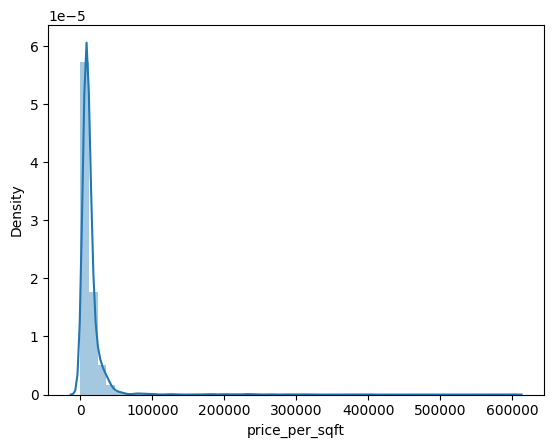

In [12]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

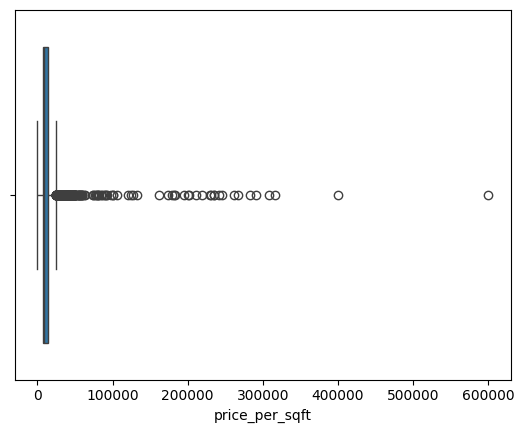

In [13]:
sns.boxplot(x=df['price_per_sqft'])

In [14]:
# Calculate the IQR for the 'price' column
Q1 = df['price_per_sqft'].quantile(0.25)
Q3 = df['price_per_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_sqft = df[(df['price_per_sqft'] < lower_bound) | (df['price_per_sqft'] > upper_bound)]

# Displaying the number of outliers and some statistics
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft['price_per_sqft'].describe()

num_outliers, outliers_sqft_stats

(354,
 count       354.000000
 mean      52592.612994
 std       61150.458507
 min       24489.000000
 25%       28208.250000
 50%       33368.500000
 75%       41982.250000
 max      600000.000000
 Name: price_per_sqft, dtype: float64)

In [15]:
outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\205471443.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['area'] = outliers_sqft['area'].apply(lambda x:x*9 if x<1000 else x)


In [16]:
outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\3686006548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  outliers_sqft['price_per_sqft'] = round((outliers_sqft['price']*10000000)/outliers_sqft['area'])


In [17]:
outliers_sqft['price_per_sqft'].describe()

count      354.000000
mean     29357.906780
std      12403.077309
min       2723.000000
25%      25562.000000
50%      29870.500000
75%      35549.500000
max      82540.000000
Name: price_per_sqft, dtype: float64

In [18]:
df.update(outliers_sqft)

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

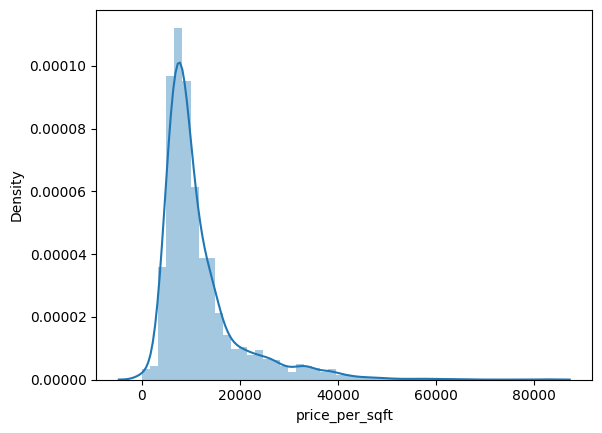

In [19]:
sns.distplot(df['price_per_sqft'])

<Axes: xlabel='price_per_sqft'>

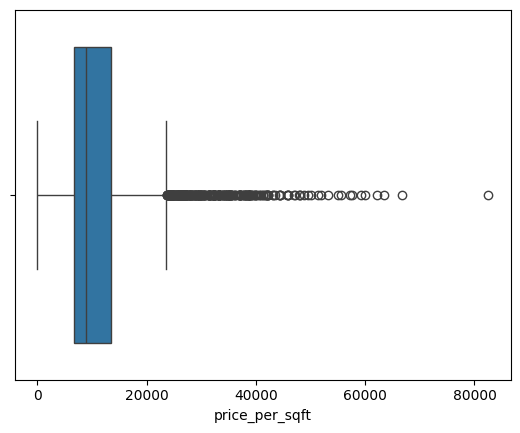

In [20]:
sns.boxplot(x=df['price_per_sqft'])

In [21]:
df[df['price_per_sqft']>50000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
74,house,independent,sector 26,26.00,82540.0,3150.0,Plot area 402(336.12 sq.m.)Built Up area: 400 ...,16,16,3+,4.0,North-West,New Property,V69088836,NaN,400.0,350.0,1,1,1,1,0,0,72
173,house,emaar mgf marbella,sector 66,18.00,55556.0,3240.0,Plot area 360(301.01 sq.m.),4,4,3+,3.0,East,Moderately Old,T69288954,NaN,3240.0,NaN,1,1,0,1,0,1,75
191,flat,unitech vistas,sector 70,9.00,57508.0,1565.0,Built Up area: 1565 (145.39 sq.m.),3,3,No Balcony,7.0,NaN,Undefined,X68863898,NaN,1565.0,NaN,0,0,0,0,0,2,0
261,house,dlf city plots,sector 26,26.00,57206.0,4545.0,Plot area 505(422.24 sq.m.),6,7,3+,2.0,North-East,New Property,Q69182156,NaN,4545.0,NaN,1,1,0,1,1,0,138
308,house,malibu towne,sector 47,8.50,53125.0,1600.0,Built Up area: 1600 (148.64 sq.m.),12,12,3+,4.0,North,New Property,B69557146,NaN,1600.0,NaN,0,0,0,0,0,0,99
1502,house,unitech escape,sector 50,10.80,60000.0,1800.0,Plot area 290(242.48 sq.m.)Built Up area: 250 ...,4,4,3,2.0,North,Relatively New,P69883714,NaN,250.0,200.0,1,1,1,1,0,0,103
1799,house,nul,sector 28,12.50,51440.0,2430.0,Plot area 270(225.75 sq.m.),16,17,3+,4.0,South,Relatively New,L69685724,NaN,2430.0,NaN,1,1,0,1,1,1,137
1894,house,emaar the palm springs,sector 54,24.00,66667.0,3600.0,Plot area 400(37.16 sq.m.),5,5,2,1.0,North-East,Old Property,O69272000,NaN,400.0,NaN,1,1,0,1,0,0,122
1931,house,independent,sector 26,14.75,51864.0,2844.0,Plot area 316(264.22 sq.m.),16,20,3+,4.0,East,New Property,D69809916,NaN,2844.0,NaN,1,1,1,1,0,0,153
2540,house,emaar the palm springs,sector 54,14.00,62222.0,2250.0,Plot area 250(209.03 sq.m.),4,5,3+,2.0,North,Old Property,O69482346,NaN,2250.0,NaN,1,1,0,0,0,0,160


In [22]:
df = df[df['price_per_sqft'] <= 50000]

<Axes: xlabel='price_per_sqft'>

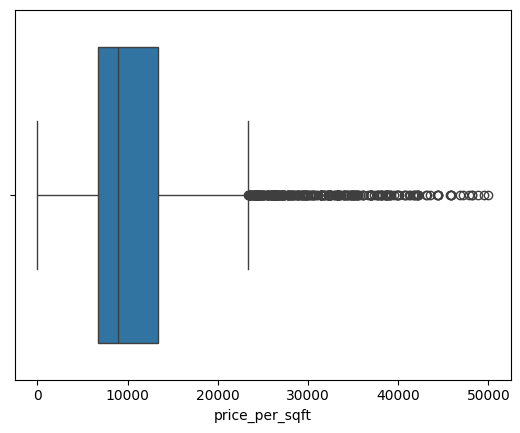

In [23]:
sns.boxplot(x=df['price_per_sqft'])

### Area

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

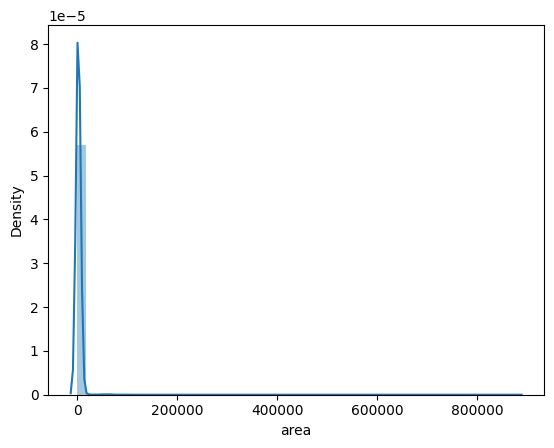

In [24]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

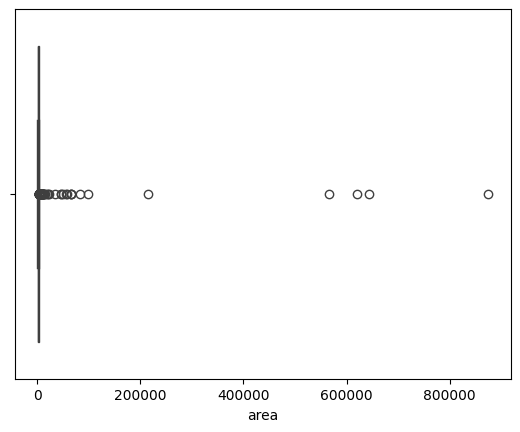

In [25]:
sns.boxplot(x=df['area'])

In [26]:
df['area'].describe()

count      3647.000000
mean       2947.783658
std       23208.036868
min         145.000000
25%        1262.000000
50%        1750.000000
75%        2350.000000
max      875000.000000
Name: area, dtype: float64

In [27]:
df[df['area'] > 100000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1394,flat,signature global solera 2,sector 107,0.51,9.0,566667.0,Carpet area: 514396 (47788.95 sq.m.),2,2,1 Balcony,3.0,North,New Property,B70122778,NaN,NaN,514396.0,0,0,0,0,0,2,44
1620,flat,hcbs sports ville,sohna road,0.35,4.0,875000.0,Built Up area: 737147 (68483.2 sq.m.),2,2,2 Balconies,8.0,NaN,Relatively New,Y69214772,NaN,737147.0,NaN,0,0,0,0,0,1,44
1940,flat,signature the roselia,sector 95,0.45,7.0,642857.0,Carpet area: 569243 (52884.41 sq.m.),2,2,2 Balconies,2.0,South-West,New Property,Y68589358,NaN,NaN,569243.0,0,0,0,0,0,2,76
2321,house,independent,sector 50,5.00,232.0,215517.0,Plot area 2(1011.71 sq.m.),6,5,3+,2.0,NaN,New Property,T68498396,NaN,2.0,NaN,1,1,0,1,1,0,0
3752,flat,ramsons kshitij,sector 95,0.31,5.0,620000.0,Carpet area: 607936 (56479.1 sq.m.),2,2,1 Balcony,1.0,North-East,Relatively New,D70174086,NaN,NaN,607936.0,1,0,0,0,1,2,65


In [28]:
df = df[df['area'] < 100000]

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

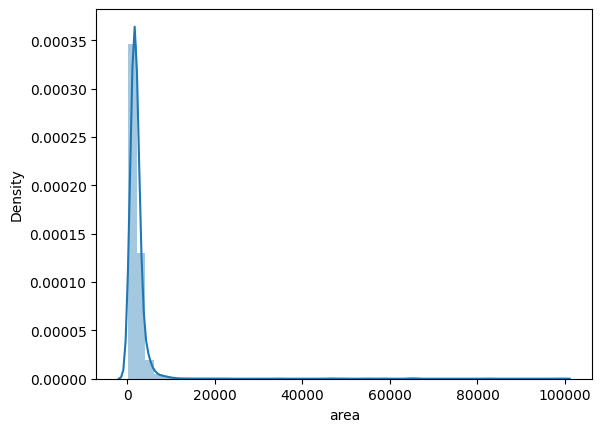

In [29]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

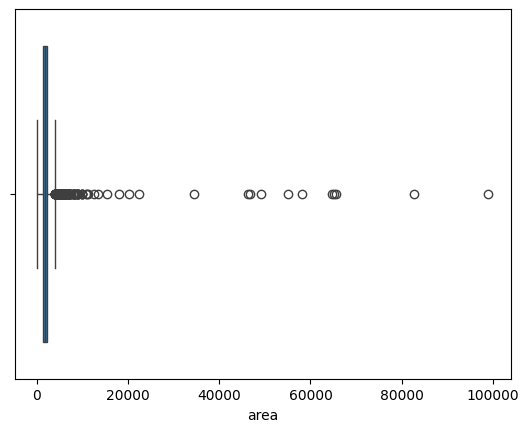

In [30]:
sns.boxplot(x=df['area'])

In [31]:
df[df['area'] > 10000].sort_values('area',ascending=False)

# 818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1633,house,independent,sector 26,18.400,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,Z69661544,NaN,NaN,11000.00,0,1,1,1,0,0,60
3105,house,ganpati heights apartment,sector 13,1.250,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,B68707994,NaN,115.0,NaN,0,0,0,0,1,2,7
783,flat,rof ananda,sector 95,0.380,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1 Balcony,12.0,North,Relatively New,C70172232,NaN,NaN,64412.00,0,0,0,0,0,2,51
1087,house,dlf city plot phase 4,sector 28,13.000,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,L68155082,NaN,NaN,7250.00,0,0,0,0,0,2,0
153,flat,rof ananda,sector 95,0.375,58.0,64655.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2 Balconies,10.0,East,New Property,U69464558,NaN,NaN,64529.00,1,0,0,0,0,2,15
1453,flat,pyramid elite,sector 86,0.460,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1 Balcony,0.0,NaN,Under Construction,M68651514,NaN,NaN,58141.00,0,0,0,0,0,2,15
85,flat,rof ananda,sector 95,0.330,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1 Balcony,13.0,South-West,Relatively New,N70172062,NaN,NaN,54917.00,0,0,0,0,0,2,37
2074,flat,signature the serenas,sohna road,0.280,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2 Balconies,1.0,North-West,Relatively New,R69765432,NaN,NaN,48811.00,1,0,0,0,0,2,37
3003,house,independent,sector 25,7.300,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,Q69161092,NaN,5800.0,5200.00,0,1,1,0,0,0,109
684,flat,ramsons kshitij,sector 95,0.245,53.0,46226.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1 Balcony,10.0,North-West,Relatively New,F70174220,NaN,NaN,45966.00,0,0,0,0,1,2,33


In [32]:
df.drop(index=[818, 1796, 1123, 2, 2356, 115, 3649, 2503, 1471], inplace=True)

In [33]:
df[df['area'] > 10000].sort_values('area',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1633,house,independent,sector 26,18.400,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,Z69661544,NaN,NaN,11000.00,0,1,1,1,0,0,60
3105,house,ganpati heights apartment,sector 13,1.250,151.0,82781.0,Plot area 115(7692.86 sq.m.),10,6,2,3.0,South-East,Old Property,B68707994,NaN,115.0,NaN,0,0,0,0,1,2,7
783,flat,rof ananda,sector 95,0.380,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1 Balcony,12.0,North,Relatively New,C70172232,NaN,NaN,64412.00,0,0,0,0,0,2,51
1087,house,dlf city plot phase 4,sector 28,13.000,1992.0,65261.0,Carpet area: 7250 (6061.92 sq.m.),10,10,3+,1.0,NaN,Undefined,L68155082,NaN,NaN,7250.00,0,0,0,0,0,2,0
153,flat,rof ananda,sector 95,0.375,58.0,64655.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2 Balconies,10.0,East,New Property,U69464558,NaN,NaN,64529.00,1,0,0,0,0,2,15
1453,flat,pyramid elite,sector 86,0.460,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1 Balcony,0.0,NaN,Under Construction,M68651514,NaN,NaN,58141.00,0,0,0,0,0,2,15
85,flat,rof ananda,sector 95,0.330,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1 Balcony,13.0,South-West,Relatively New,N70172062,NaN,NaN,54917.00,0,0,0,0,0,2,37
2074,flat,signature the serenas,sohna road,0.280,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2 Balconies,1.0,North-West,Relatively New,R69765432,NaN,NaN,48811.00,1,0,0,0,0,2,37
3003,house,independent,sector 25,7.300,1560.0,46795.0,Plot area 215(179.77 sq.m.)Built Up area: 5800...,9,9,2,3.0,North-West,Relatively New,Q69161092,NaN,5800.0,5200.00,0,1,1,0,0,0,109
684,flat,ramsons kshitij,sector 95,0.245,53.0,46226.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1 Balcony,10.0,North-West,Relatively New,F70174220,NaN,NaN,45966.00,0,0,0,0,1,2,33


In [34]:
df.loc[48,'area'] = 115*9
df.loc[300,'area'] = 7250
df.loc[2666,'area'] = 5800
df.loc[1358,'area'] = 2660
df.loc[3195,'area'] = 2850
df.loc[2131,'area'] = 1812
df.loc[3088,'area'] = 2160
df.loc[3444,'area'] = 1175

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\91062565.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area'])


<Axes: xlabel='area', ylabel='Density'>

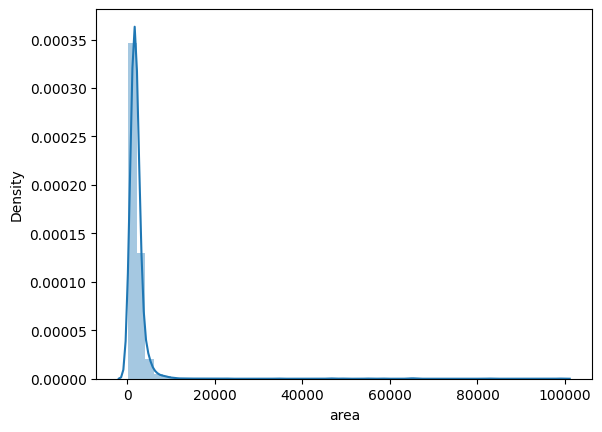

In [35]:
sns.distplot(df['area'])

<Axes: xlabel='area'>

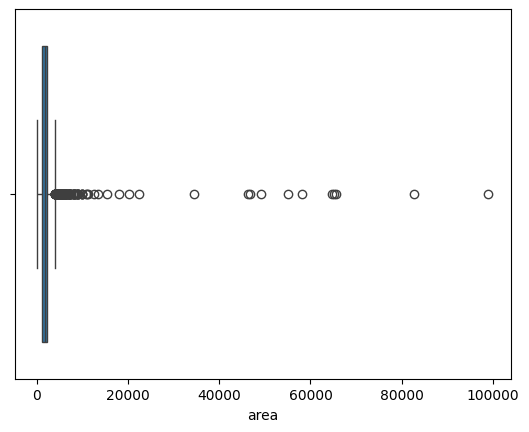

In [36]:
sns.boxplot(x=df['area'])

In [37]:
df['area'].describe()

count     3633.000000
mean      2152.362510
std       3628.328692
min        145.000000
25%       1261.000000
50%       1750.000000
75%       2344.000000
max      98978.000000
Name: area, dtype: float64

### Bedroom

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

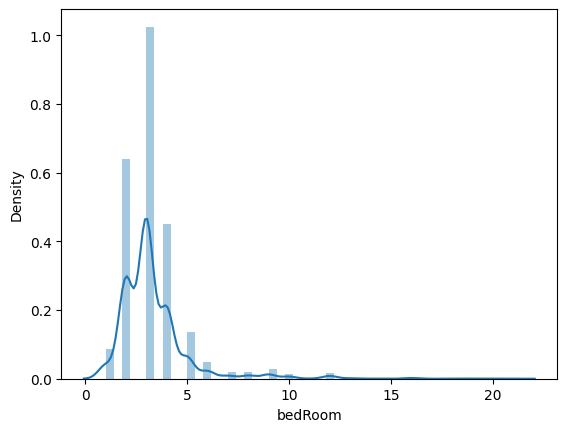

In [38]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

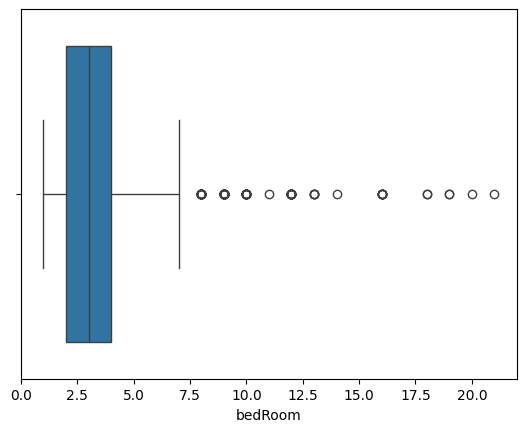

In [39]:
sns.boxplot(x=df['bedRoom'])

In [40]:
df['bedRoom'].describe()

count    3633.000000
mean        3.332508
std         1.831438
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max        21.000000
Name: bedRoom, dtype: float64

In [41]:
df[df['bedRoom'] > 10].sort_values('bedRoom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
2912,house,independent,sector 54,5.00,43066.0,1161.0,Plot area 129(107.86 sq.m.),21,21,3+,5.0,North,Relatively New,R69483164,NaN,1161.0,NaN,0,1,0,0,0,1,49
3467,house,independent,sector 43,4.50,39062.0,1152.0,Plot area 128(107.02 sq.m.),20,20,3+,4.0,East,Relatively New,V69218808,NaN,1152.0,NaN,0,1,0,0,0,1,22
2347,house,independent,sector 17a,3.93,24214.0,1623.0,Plot area 1623(150.78 sq.m.)Built Up area: 162...,19,17,3,4.0,North-West,Relatively New,P70082842,NaN,1622.0,NaN,1,1,1,1,0,2,74
2647,house,independent,sector 17a,3.87,5160.0,7500.0,Plot area 1623(150.78 sq.m.)Built Up area: 750...,19,17,3+,5.0,North-West,Relatively New,B65708738,NaN,7500.0,NaN,1,0,1,0,0,2,68
2951,house,private house,sector 55,7.05,46906.0,1503.0,Plot area 167(139.63 sq.m.),18,18,3+,4.0,North-East,Relatively New,H69788864,NaN,1503.0,NaN,0,0,0,0,1,1,57
3756,house,independent,sector 54,5.50,38194.0,1440.0,Plot area 160(133.78 sq.m.),18,18,3+,4.0,South-West,Relatively New,Q69197908,NaN,1440.0,NaN,0,1,0,0,0,1,70
1581,house,independent,sector 43,13.50,50000.0,2700.0,Plot area 300(250.84 sq.m.),16,16,3+,4.0,North-West,Relatively New,D69611236,NaN,2700.0,NaN,1,1,0,1,1,2,41
1251,house,independent,sector 56,12.39,45889.0,2700.0,Plot area 300(250.84 sq.m.),16,18,3+,4.0,North-East,New Property,D68743678,NaN,2700.0,NaN,0,1,0,1,0,0,49
438,house,independent,sector 55,9.19,34037.0,2700.0,Plot area 300(250.84 sq.m.),16,18,2,4.0,West,New Property,V68700636,NaN,2700.0,NaN,0,1,0,1,0,0,49
1055,house,luxury dlf city floors,sector 26,20.00,48888.0,4091.0,Plot area 500(418.06 sq.m.),16,16,3+,4.0,NaN,New Property,E67952012,NaN,500.0,NaN,0,1,0,0,0,0,31


In [42]:
df = df[df['bedRoom'] <= 10]

In [43]:
df.shape

(3588, 24)

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\1691983684.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bedRoom'])


<Axes: xlabel='bedRoom', ylabel='Density'>

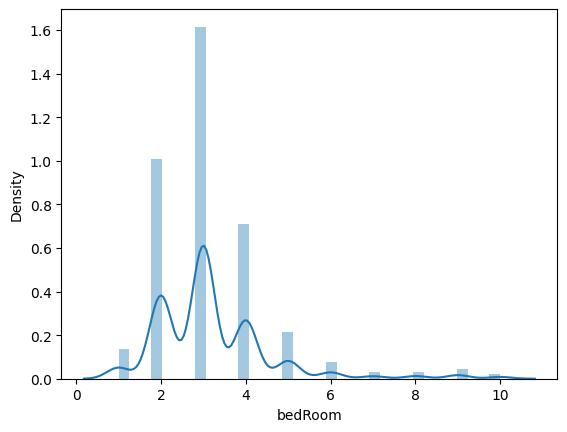

In [44]:
sns.distplot(df['bedRoom'])

<Axes: xlabel='bedRoom'>

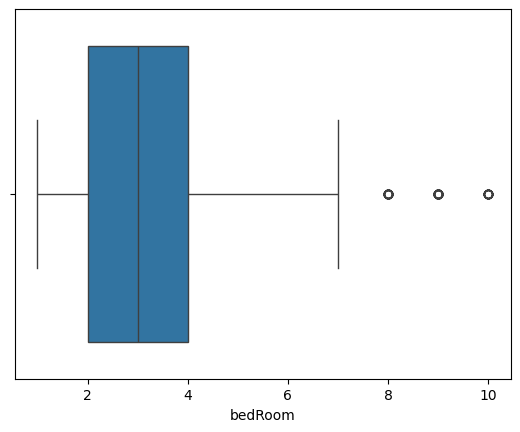

In [45]:
sns.boxplot(x=df['bedRoom'])

In [46]:
df['bedRoom'].describe()

count    3588.00000
mean        3.20262
std         1.39573
min         1.00000
25%         2.00000
50%         3.00000
75%         4.00000
max        10.00000
Name: bedRoom, dtype: float64

### Bathroom

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\2904465235.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bathroom'])


<Axes: xlabel='bathroom', ylabel='Density'>

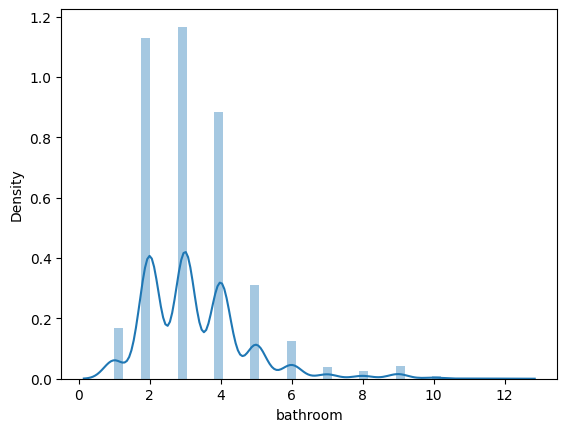

In [47]:
sns.distplot(df['bathroom'])

<Axes: xlabel='bathroom'>

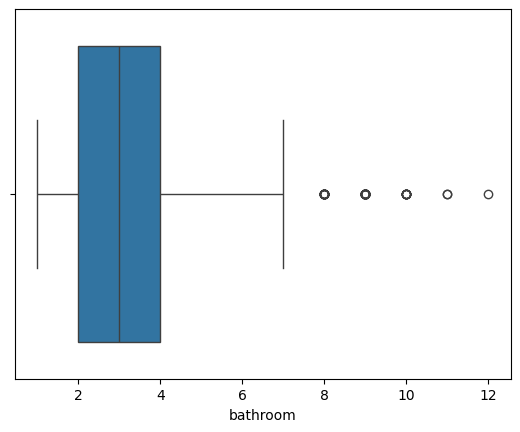

In [48]:
sns.boxplot(x=df['bathroom'])

In [49]:
df[df['bathroom'] > 10].sort_values('bathroom',ascending=False)

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
446,house,adani brahma samsara,sector 60,18.02,28200.0,6390.0,Built Up area: 6390 (593.65 sq.m.),9,12,3+,3.0,North-East,Relatively New,Y67109428,NaN,6390.0,NaN,0,1,0,0,0,0,146
1403,house,independent,sector 39,7.00,10000.0,7000.0,Plot area 350(32.52 sq.m.)Built Up area: 7000 ...,10,11,3+,4.0,South-East,Relatively New,A65044918,NaN,7000.0,NaN,0,0,0,1,0,0,38
1526,house,independent,sector 24,11.00,28902.0,3806.0,Plot area 3806.45(353.63 sq.m.)Built Up area: ...,8,11,3+,3.0,East,Old Property,Y787895,NaN,5000.0,NaN,1,1,0,1,1,0,39


In [50]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,pioneer araya,sector 62,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,10.0,North-East,Relatively New,J69118026,5514.0,NaN,NaN,0,1,0,0,0,0,153
3,house,independent,sector 39,1.60,17937.0,892.0,Plot area 892(82.87 sq.m.),1,1,2,2.0,NaN,Old Property,X67948578,NaN,892.0,NaN,0,0,0,0,0,2,40
4,flat,tulip purple,sector 69,1.92,8000.0,2400.0,Super Built up area 2400(222.97 sq.m.),4,5,3+ Balconies,5.0,East,Relatively New,O69569386,2400.0,NaN,NaN,0,1,0,0,0,0,158
5,flat,corona optus,sector 37c,1.43,7185.0,1990.0,Super Built up area 1990(184.88 sq.m.)Carpet a...,3,3,3+ Balconies,2.0,North-West,Relatively New,N70044190,1990.0,NaN,1700.0,1,1,0,0,1,2,49
6,flat,emaar gurgaon greens,sector 102,1.45,8787.0,1650.0,Super Built up area 1650(153.29 sq.m.),3,3,3 Balconies,7.0,North-East,Relatively New,C68648152,1650.0,NaN,NaN,0,1,0,0,0,2,159


### super built up area

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\4184943455.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['super_built_up_area'])


<Axes: xlabel='super_built_up_area', ylabel='Density'>

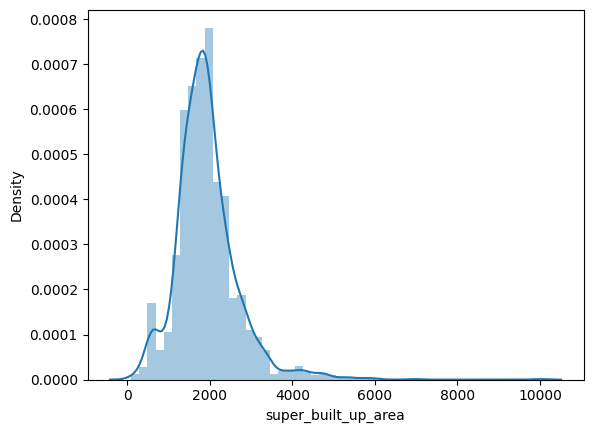

In [51]:
sns.distplot(df['super_built_up_area'])

<Axes: xlabel='super_built_up_area'>

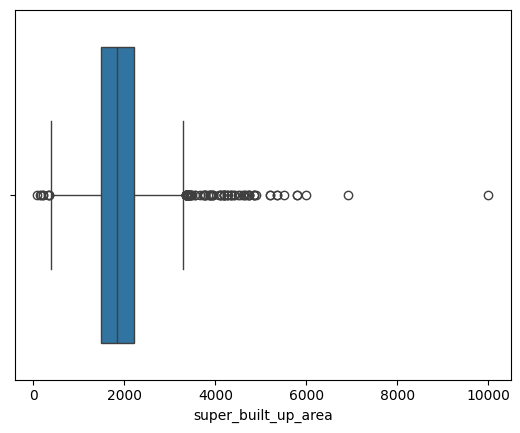

In [52]:
sns.boxplot(x=df['super_built_up_area'])

In [53]:
df['super_built_up_area'].describe()

count     1873.000000
mean      1925.699172
std        764.438326
min         89.000000
25%       1480.000000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

In [54]:
df[df['super_built_up_area'] > 6000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
3468,flat,bestech park view grand spa,sector 81,4.7,6786.0,6926.0,Super Built up area 6926(643.45 sq.m.),4,4,3+ Balconies,19.0,North,Relatively New,R61758448,6926.0,NaN,NaN,0,1,0,0,0,0,140
3776,flat,krrish provence estate,gwal pahari,7.5,7500.0,10000.0,Super Built up area 10000(929.03 sq.m.),5,6,3+ Balconies,23.0,North-East,Relatively New,V69711876,10000.0,NaN,NaN,0,1,0,1,1,2,49


### built up area

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\3494228458.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

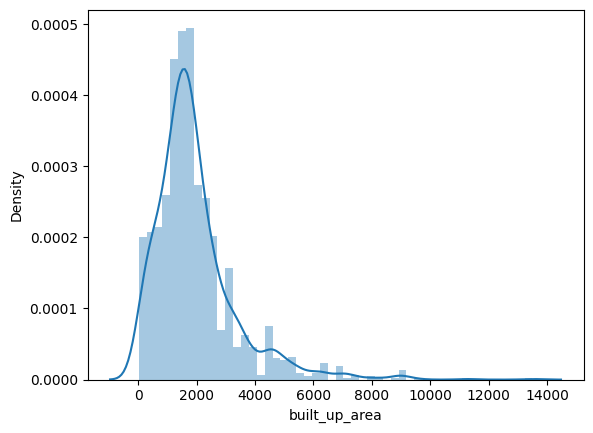

In [55]:
sns.distplot(df['built_up_area'])

<Axes: xlabel='built_up_area'>

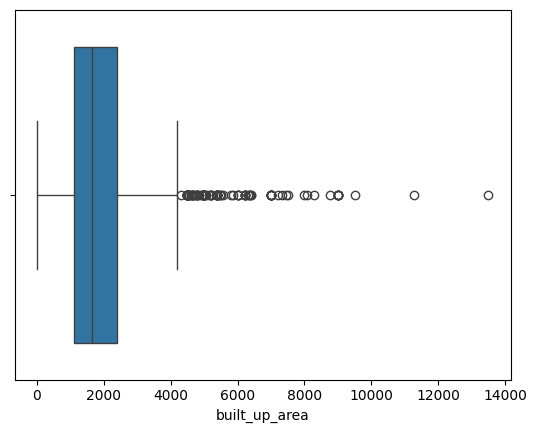

In [56]:
sns.boxplot(x=df['built_up_area'])

In [57]:
df[df['built_up_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1700,house,independent,sector 43,27.50,24366.0,11286.0,Plot area 1254(1048.5 sq.m.),6,7,3+,3.0,North-East,Relatively New,F69574832,NaN,11286.0,NaN,1,1,0,1,1,0,42
3540,house,independent,sector 4,0.85,630.0,13492.0,Plot area 1500(1254.19 sq.m.),3,3,1,1.0,North,Relatively New,A69936182,NaN,13500.0,NaN,0,0,0,0,1,2,0


### carpet area

C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\3905767603.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['carpet_area'])


<Axes: xlabel='carpet_area', ylabel='Density'>

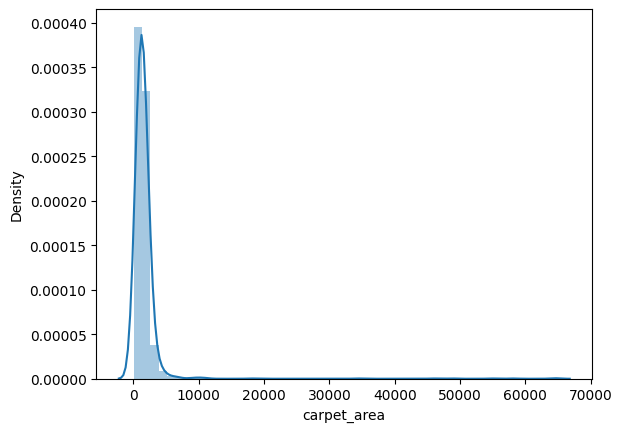

In [58]:
sns.distplot(df['carpet_area'])

<Axes: xlabel='carpet_area'>

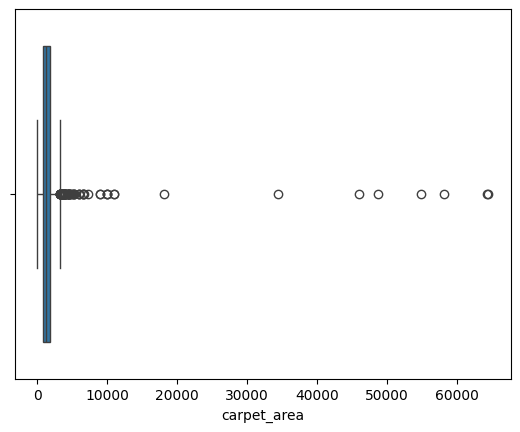

In [59]:
sns.boxplot(x=df['carpet_area'])

In [60]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
85,flat,rof ananda,sector 95,0.330,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1 Balcony,13.0,South-West,Relatively New,N70172062,NaN,NaN,54917.0,0,0,0,0,0,2,37
153,flat,rof ananda,sector 95,0.375,58.0,64655.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2 Balconies,10.0,East,New Property,U69464558,NaN,NaN,64529.0,1,0,0,0,0,2,15
684,flat,ramsons kshitij,sector 95,0.245,53.0,46226.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1 Balcony,10.0,North-West,Relatively New,F70174220,NaN,NaN,45966.0,0,0,0,0,1,2,33
783,flat,rof ananda,sector 95,0.380,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1 Balcony,12.0,North,Relatively New,C70172232,NaN,NaN,64412.0,0,0,0,0,0,2,51
869,flat,rof ananda,sector 95,0.210,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1,1,1 Balcony,13.0,North,Relatively New,P70171750,NaN,NaN,34401.0,0,0,0,0,0,2,68
1453,flat,pyramid elite,sector 86,0.460,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1 Balcony,0.0,NaN,Under Construction,M68651514,NaN,NaN,58141.0,0,0,0,0,0,2,15
1633,house,independent,sector 26,18.400,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,Z69661544,NaN,NaN,11000.0,0,1,1,1,0,0,60
1781,flat,m3m golfestate,sector 65,13.200,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3 Balconies,13.0,North,Moderately Old,T68297184,NaN,NaN,11000.0,0,1,0,0,0,2,60
2074,flat,signature the serenas,sohna road,0.280,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2 Balconies,1.0,North-West,Relatively New,R69765432,NaN,NaN,48811.0,1,0,0,0,0,2,37
2337,flat,godrej air,sector 85,2.500,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+ Balconies,16.0,North-East,Under Construction,I69226618,NaN,NaN,18122.0,1,0,0,1,1,0,44


In [61]:
df.loc[2131,'carpet_area'] = 1812

In [62]:
df[df['carpet_area'] > 10000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
85,flat,rof ananda,sector 95,0.330,60.0,55000.0,Carpet area: 54917 (5101.96 sq.m.),2,2,1 Balcony,13.0,South-West,Relatively New,N70172062,NaN,NaN,54917.0,0,0,0,0,0,2,37
153,flat,rof ananda,sector 95,0.375,58.0,64655.0,Carpet area: 64529 (5994.94 sq.m.),2,2,2 Balconies,10.0,East,New Property,U69464558,NaN,NaN,64529.0,1,0,0,0,0,2,15
684,flat,ramsons kshitij,sector 95,0.245,53.0,46226.0,Carpet area: 45966 (4270.38 sq.m.),2,2,1 Balcony,10.0,North-West,Relatively New,F70174220,NaN,NaN,45966.0,0,0,0,0,1,2,33
783,flat,rof ananda,sector 95,0.380,58.0,65517.0,Carpet area: 64412 (5984.07 sq.m.),3,2,1 Balcony,12.0,North,Relatively New,C70172232,NaN,NaN,64412.0,0,0,0,0,0,2,51
869,flat,rof ananda,sector 95,0.210,61.0,34426.0,Carpet area: 34401 (3195.96 sq.m.),1,1,1 Balcony,13.0,North,Relatively New,P70171750,NaN,NaN,34401.0,0,0,0,0,0,2,68
1453,flat,pyramid elite,sector 86,0.460,79.0,58228.0,Carpet area: 58141 (5401.48 sq.m.),2,2,1 Balcony,0.0,NaN,Under Construction,M68651514,NaN,NaN,58141.0,0,0,0,0,0,2,15
1633,house,independent,sector 26,18.400,1859.0,98978.0,Plot area 502(419.74 sq.m.)Carpet area: 11000 ...,6,8,3+,4.0,South,Relatively New,Z69661544,NaN,NaN,11000.0,0,1,1,1,0,0,60
1781,flat,m3m golfestate,sector 65,13.200,12000.0,11000.0,Carpet area: 11000 (1021.93 sq.m.),4,4,3 Balconies,13.0,North,Moderately Old,T68297184,NaN,NaN,11000.0,0,1,0,0,0,2,60
2074,flat,signature the serenas,sohna road,0.280,57.0,49123.0,Carpet area: 48811 (4534.69 sq.m.),1,1,2 Balconies,1.0,North-West,Relatively New,R69765432,NaN,NaN,48811.0,1,0,0,0,0,2,37
2337,flat,godrej air,sector 85,2.500,1379.0,18129.0,Carpet area: 18122 (1683.59 sq.m.),4,5,3+ Balconies,16.0,North-East,Under Construction,I69226618,NaN,NaN,18122.0,1,0,0,1,1,0,44


In [63]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,pioneer araya,sector 62,10.75,19500.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,10.0,North-East,Relatively New,J69118026,5514.0,NaN,NaN,0,1,0,0,0,0,153
3,house,independent,sector 39,1.60,17937.0,892.0,Plot area 892(82.87 sq.m.),1,1,2,2.0,NaN,Old Property,X67948578,NaN,892.0,NaN,0,0,0,0,0,2,40
4,flat,tulip purple,sector 69,1.92,8000.0,2400.0,Super Built up area 2400(222.97 sq.m.),4,5,3+ Balconies,5.0,East,Relatively New,O69569386,2400.0,NaN,NaN,0,1,0,0,0,0,158
5,flat,corona optus,sector 37c,1.43,7185.0,1990.0,Super Built up area 1990(184.88 sq.m.)Carpet a...,3,3,3+ Balconies,2.0,North-West,Relatively New,N70044190,1990.0,NaN,1700.0,1,1,0,0,1,2,49
6,flat,emaar gurgaon greens,sector 102,1.45,8787.0,1650.0,Super Built up area 1650(153.29 sq.m.),3,3,3 Balconies,7.0,North-East,Relatively New,C68648152,1650.0,NaN,NaN,0,1,0,0,0,2,159


C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\3385064764.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['luxury_score'])


<Axes: xlabel='luxury_score', ylabel='Density'>

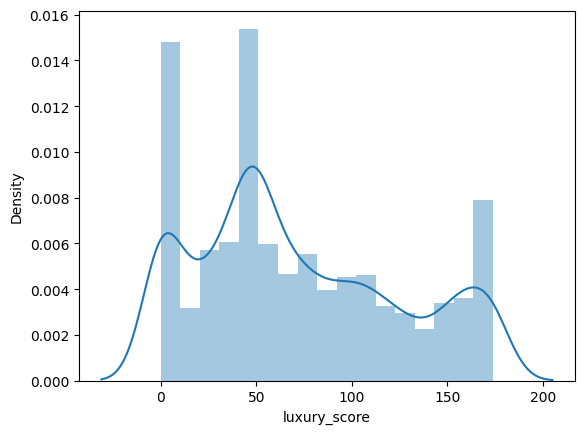

In [64]:
sns.distplot(df['luxury_score'])

<Axes: ylabel='luxury_score'>

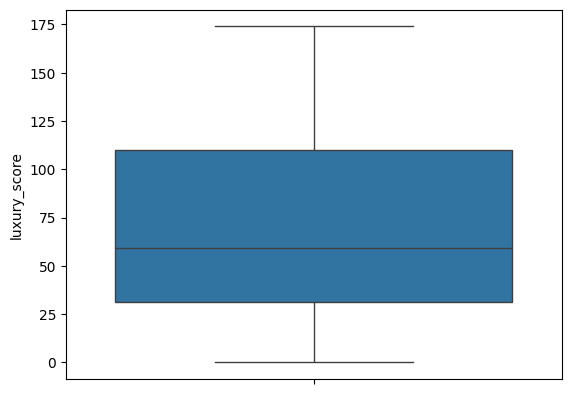

In [65]:
sns.boxplot(df['luxury_score'])

In [66]:
df.shape

(3588, 24)

In [67]:
df['price_per_sqft'] = round((df['price']*10000000)/df['area'])

In [68]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,pioneer araya,sector 62,10.75,19499.0,5513.0,Super Built up area 5514(512.27 sq.m.),5,7,3 Balconies,10.0,North-East,Relatively New,J69118026,5514.0,NaN,NaN,0,1,0,0,0,0,153
3,house,independent,sector 39,1.60,17937.0,892.0,Plot area 892(82.87 sq.m.),1,1,2,2.0,NaN,Old Property,X67948578,NaN,892.0,NaN,0,0,0,0,0,2,40
4,flat,tulip purple,sector 69,1.92,8000.0,2400.0,Super Built up area 2400(222.97 sq.m.),4,5,3+ Balconies,5.0,East,Relatively New,O69569386,2400.0,NaN,NaN,0,1,0,0,0,0,158
5,flat,corona optus,sector 37c,1.43,7186.0,1990.0,Super Built up area 1990(184.88 sq.m.)Carpet a...,3,3,3+ Balconies,2.0,North-West,Relatively New,N70044190,1990.0,NaN,1700.0,1,1,0,0,1,2,49
6,flat,emaar gurgaon greens,sector 102,1.45,8788.0,1650.0,Super Built up area 1650(153.29 sq.m.),3,3,3 Balconies,7.0,North-East,Relatively New,C68648152,1650.0,NaN,NaN,0,1,0,0,0,2,159


C:\Users\abhay\AppData\Local\Temp\ipykernel_20476\2186227091.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['price_per_sqft'])


<Axes: xlabel='price_per_sqft', ylabel='Density'>

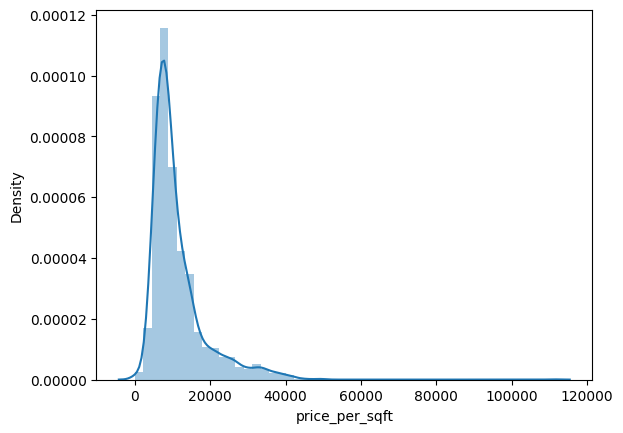

In [69]:
sns.distplot(df['price_per_sqft'])

<Axes: ylabel='price_per_sqft'>

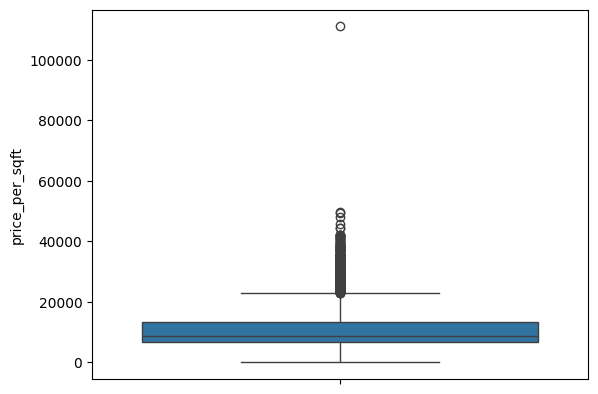

In [70]:
sns.boxplot(df['price_per_sqft'])

In [71]:
df[df['price_per_sqft'] > 42000]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
48,house,unitech uniworld resorts,sector 33,11.5,111111.0,1035.0,Plot area 520(434.79 sq.m.),5,6,3+,4.0,East,Relatively New,T68843520,NaN,4680.0,NaN,0,1,0,0,0,2,84
151,house,independent,sector 25,13.0,45710.0,2844.0,Plot area 316(264.22 sq.m.),6,8,3+,NaN,NaN,Relatively New,R67662264,NaN,2844.0,NaN,1,1,1,1,0,1,0
395,house,independent,sector 43,9.5,42222.0,2250.0,Plot area 302(252.51 sq.m.)Built Up area: 300 ...,5,5,3+,2.0,North-East,Relatively New,B70289660,NaN,300.0,250.0,0,1,0,1,0,0,88
799,house,independent,sector 55,5.0,44444.0,1125.0,Plot area 125(104.52 sq.m.)Built Up area: 115 ...,9,9,3+,5.0,East,New Property,L69907826,NaN,115.0,100.0,0,0,0,0,1,0,44
2131,house,independent,sector 41,9.0,49669.0,1812.0,Plot area 360(301.01 sq.m.),8,5,3+,3.0,NaN,Old Property,I69453422,NaN,3240.0,1812.0,0,1,1,1,0,0,26
2179,house,independent,sector 105,9.9,49500.0,2000.0,Built Up area: 2000 (185.81 sq.m.)Carpet area:...,2,2,2,3.0,North,Undefined,J66250436,NaN,2000.0,1800.0,0,0,0,0,0,2,0
2582,house,independent,sector 26,19.0,42222.0,4500.0,Plot area 500(418.06 sq.m.),6,8,3+,3.0,East,Moderately Old,M70013508,NaN,4500.0,NaN,1,1,1,1,0,0,103
2761,house,independent,sector 26,20.0,44444.0,4500.0,Plot area 500(418.06 sq.m.),5,7,3+,3.0,West,Relatively New,T69775462,NaN,4500.0,NaN,0,1,0,1,0,1,97
2989,house,independent,sector 28,12.0,42194.0,2844.0,Plot area 316(264.22 sq.m.),4,5,3+,4.0,East,Relatively New,A69428298,NaN,2844.0,NaN,0,1,1,1,0,0,60
3352,house,dlf city plots,sector 26,19.0,42054.0,4518.0,Plot area 502(419.74 sq.m.),6,6,3,2.0,East,Relatively New,P68648594,NaN,4518.0,NaN,1,1,0,0,0,0,121


In [72]:
x = df[df['price_per_sqft'] <= 20000]
(x['area']/x['bedRoom']).quantile(0.02)

np.float64(186.06)

In [73]:
df[(df['area']/df['bedRoom'])<183]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_id,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
154,house,ss omnia,sector 86,0.42,9333.0,450.0,Plot area 50(4.65 sq.m.),5,3,2,3.0,NaN,Relatively New,Y62955100,NaN,50.0,NaN,0,0,0,0,0,2,0
184,house,shri shyam residency,sector 104,0.62,12400.0,500.0,Plot area 500(46.45 sq.m.)Built Up area: 900 s...,3,3,1,2.0,NaN,Moderately Old,J49925954,NaN,900.0,480.0,0,0,0,0,1,1,8
221,house,sector 38 rwa,sector 38,4.30,28782.0,1494.0,Plot area 166(138.8 sq.m.)Built Up area: 165 s...,9,9,3+,3.0,East,Relatively New,E69566242,NaN,165.0,164.0,0,0,0,1,1,0,41
237,house,"bhim nagar, sector 6",sector 6,0.85,14096.0,603.0,Plot area 67(6.22 sq.m.),5,2,2,1.0,NaN,Old Property,X61115738,NaN,67.0,NaN,0,0,0,1,0,2,29
260,house,independent,sector 9,1.25,8735.0,1431.0,Plot area 159(132.94 sq.m.),10,6,3+,3.0,NaN,Old Property,J69656828,NaN,1431.0,NaN,0,0,0,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3569,house,independent,sector 4,0.92,15257.0,603.0,Plot area 67(56.02 sq.m.),4,4,3,4.0,East,Moderately Old,N68485626,NaN,603.0,NaN,0,0,0,0,1,2,0
3612,house,independent,sector 47,0.99,17188.0,576.0,Plot area 64(53.51 sq.m.),4,4,3,4.0,NaN,Relatively New,I70178342,NaN,576.0,NaN,0,0,0,0,0,2,13
3658,house,independent,sector 4,0.65,11111.0,585.0,Plot area 65(54.35 sq.m.),4,2,2,NaN,NaN,Moderately Old,R65283270,NaN,585.0,NaN,0,0,0,0,0,2,0
3683,house,housing board colony,sector 28,2.10,23333.0,900.0,Plot area 100(83.61 sq.m.),8,8,3+,4.0,South-East,Moderately Old,D68648118,NaN,900.0,NaN,0,0,0,0,1,0,38
